In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio

import os, random
import numpy as np
import rasterio
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import label

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_PATH = "/content/drive/MyDrive/MARIDA"
PATCH_PATH = BASE_PATH + "/patches"
MODEL_PATH = "/content/drive/MyDrive/attention_unet_best.keras"

DEBRIS_CLASS = 1
TH = 0.15   # same as your working setup

In [ ]:
def load_patch_by_name(name):
    name = name.replace(".tif","")
    full = "S2_" + name

    for scene in os.listdir(PATCH_PATH):
        sp = os.path.join(PATCH_PATH, scene)

        img_p  = os.path.join(sp, full+".tif")
        mask_p = os.path.join(sp, full+"_cl.tif")

        if os.path.exists(img_p) and os.path.exists(mask_p):
            with rasterio.open(img_p) as src:
                img = src.read().astype(np.float32)
            with rasterio.open(mask_p) as src:
                mask = src.read(1)
            return img, mask

    return None, None

In [ ]:
def compute_indices(img):
    img = img / 10000.0

    blue, green, red = img[1], img[2], img[3]
    nir, swir1, re2  = img[7], img[10], img[5]

    ndvi = (nir-red)/(nir+red+1e-6)
    ndwi = (green-nir)/(green+nir+1e-6)
    fdi  = nir - (re2 + (swir1-re2))

    f = np.stack([red,green,blue,nir,ndvi,ndwi,fdi],axis=-1)

    f = (f - np.mean(f)) / (np.std(f)+1e-6)
    return f.astype(np.float32)

In [ ]:
all_patches = []

for s in os.listdir(PATCH_PATH):
    for f in os.listdir(os.path.join(PATCH_PATH,s)):
        if f.endswith(".tif") and not f.endswith("_cl.tif"):
            all_patches.append(f.replace("S2_","").replace(".tif",""))

def has_debris(n):
    _, m = load_patch_by_name(n)
    return m is not None and np.sum(m==DEBRIS_CLASS)>0

debris, empty = [], []

for n in tqdm(all_patches):
    if has_debris(n): debris.append(n)
    else: empty.append(n)

random.shuffle(debris)
random.shuffle(empty)

split_d = int(0.7*len(debris))
split_e = int(0.7*len(empty))

train_list = debris[:split_d] + empty[:split_e]
val_list   = debris[split_d:] + empty[split_e:]

train_list = train_list + debris[:split_d]*7
random.shuffle(train_list)

100%|██████████| 2779/2779 [02:14<00:00, 20.60it/s]


In [ ]:
class DataGen(tf.keras.utils.Sequence):
    def __init__(self, plist, bs=4, **kwargs):
        super().__init__(**kwargs)
        self.plist = plist
        self.bs = bs

    def __len__(self):
        return int(np.ceil(len(self.plist)/self.bs))

    def __getitem__(self,i):
        batch = self.plist[i*self.bs:(i+1)*self.bs]

        X,y = [],[]

        for n in batch:
            img,mask = load_patch_by_name(n)
            if img is None: continue

            f = compute_indices(img)
            if not np.isfinite(f).all(): continue

            X.append(f)
            y.append((mask==DEBRIS_CLASS).astype(np.float32)[...,None])

        if len(X)==0:
            return self.__getitem__(random.randint(0,len(self)-1))

        return np.array(X), np.array(y)

In [ ]:
bce = tf.keras.losses.BinaryCrossentropy()

def dice_loss(y_true,y_pred):
    inter=tf.reduce_sum(y_true*y_pred)
    denom=tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)
    return 1-(2*inter+1e-6)/(denom+1e-6)

def focal_loss(y_true,y_pred,gamma=3):
    y_pred=tf.clip_by_value(y_pred,1e-6,1-1e-6)
    pt=y_true*y_pred+(1-y_true)*(1-y_pred)
    return tf.reduce_mean(-tf.pow(1-pt,gamma)*tf.math.log(pt))

def weighted_bce(y_true,y_pred):
    weights = y_true*20 + 1
    return tf.reduce_mean(weights * bce(y_true,y_pred))

def combined_loss(y_true,y_pred):
    return weighted_bce(y_true,y_pred)+dice_loss(y_true,y_pred)+focal_loss(y_true,y_pred)

In [ ]:
def iou_metric(y_true,y_pred):
    y_pred=tf.cast(y_pred>TH,tf.float32)
    inter=tf.reduce_sum(y_true*y_pred,[1,2,3])
    union=tf.reduce_sum(y_true+y_pred,[1,2,3])-inter
    return tf.reduce_mean((inter+1e-6)/(union+1e-6))
def dice_metric(y_true,y_pred):
    y_pred=tf.cast(y_pred>TH,tf.float32)
    inter=tf.reduce_sum(y_true*y_pred,[1,2,3])
    denom=tf.reduce_sum(y_true+y_pred,[1,2,3])
    return tf.reduce_mean((2*inter+1e-6)/(denom+1e-6))
def precision_metric(y_true,y_pred):
    y_pred=tf.cast(y_pred>TH,tf.float32)
    tp=tf.reduce_sum(y_true*y_pred,[1,2,3])
    fp=tf.reduce_sum((1-y_true)*y_pred,[1,2,3])
    return tf.reduce_mean((tp+1e-6)/(tp+fp+1e-6))
def recall_metric(y_true,y_pred):
    y_pred=tf.cast(y_pred>TH,tf.float32)
    tp=tf.reduce_sum(y_true*y_pred,[1,2,3])
    fn=tf.reduce_sum(y_true*(1-y_pred),[1,2,3])
    return tf.reduce_mean((tp+1e-6)/(tp+fn+1e-6))
def f1_metric(y_true,y_pred):
    p=precision_metric(y_true,y_pred)
    r=recall_metric(y_true,y_pred)
    return 2*p*r/(p+r+1e-6)

In [ ]:
def attention_block(x,g,f):
    theta=tf.keras.layers.Conv2D(f,1)(x)
    phi=tf.keras.layers.Conv2D(f,1)(g)
    add=tf.keras.layers.Activation('relu')(theta+phi)
    psi=tf.keras.layers.Conv2D(1,1)(add)
    psi=tf.keras.layers.Activation('sigmoid')(psi)
    return x*psi
def build_model(shape):
    i=tf.keras.layers.Input(shape)
    c1=tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(i)
    c1=tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(c1)
    p1=tf.keras.layers.MaxPooling2D()(c1)
    c2=tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(p1)
    c2=tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(c2)
    u=tf.keras.layers.UpSampling2D()(c2)
    att=attention_block(c1,u,16)
    u=tf.keras.layers.concatenate([u,att])
    c3=tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(u)
    c3=tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(c3)
    o=tf.keras.layers.Conv2D(1,1,activation='sigmoid')(c3)
    return tf.keras.Model(i,o)

In [ ]:
train_gen=DataGen(train_list)
val_gen=DataGen(val_list)

In [ ]:
train_gen=DataGen(train_list)
val_gen=DataGen(val_list)

model=build_model((256,256,7))

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=[iou_metric,dice_metric,precision_metric,recall_metric,f1_metric]
)

cb1=tf.keras.callbacks.ModelCheckpoint(MODEL_PATH,monitor='val_iou_metric',save_best_only=True,mode='max')
cb2=tf.keras.callbacks.EarlyStopping(monitor='val_iou_metric',patience=3,mode='max',restore_best_weights=True)

history=model.fit(train_gen,validation_data=val_gen,epochs=25,callbacks=[cb1,cb2])

Epoch 1/25
943/943 ━━━━━━━━━━━━━━━━━━━━ 1473s 2s/step - dice_metric: 0.0603 - f1_metric: 0.1094 - iou_metric: 0.0497 - loss: 0.9822 - precision_metric: 0.1526 - recall_metric: 0.3470 - val_dice_metric: 0.4518 - val_f1_metric: 0.5164 - val_iou_metric: 0.4402 - val_loss: 0.9375 - val_precision_metric: 0.4738 - val_recall_metric: 0.9210
Epoch 2/25
943/943 ━━━━━━━━━━━━━━━━━━━━ 1443s 2s/step - dice_metric: 0.3302 - f1_metric: 0.4364 - iou_metric: 0.2697 - loss: 0.7644 - precision_metric: 0.4516 - recall_metric: 0.6319 - val_dice_metric: 0.5398 - val_f1_metric: 0.6002 - val_iou_metric: 0.5272 - val_loss: 0.9109 - val_precision_metric: 0.5675 - val_recall_metric: 0.9185
Epoch 3/25
943/943 ━━━━━━━━━━━━━━━━━━━━ 1457s 2s/step - dice_metric: 0.3871 - f1_metric: 0.4835 - iou_metric: 0.3166 - loss: 0.6963 - precision_metric: 0.4731 - recall_metric: 0.6568 - val_dice_metric: 0.5841 - val_f1_metric: 0.6451 - val_iou_metric: 0.5692 - val_loss: 0.8981 - val_precision_metric: 0.6035 - val_recall_metric:

In [ ]:
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'combined_loss':combined_loss,
        'iou_metric':iou_metric,
        'dice_metric':dice_metric,
        'precision_metric':precision_metric,
        'recall_metric':recall_metric,
        'f1_metric':f1_metric
    }
)

In [ ]:
res=model.evaluate(val_gen)

print("\nFINAL PERFORMANCE")
print("IoU:",res[1])
print("Dice:",res[2])
print("Precision:",res[3])
print("Recall:",res[4])
print("F1:",res[5])

209/209 ━━━━━━━━━━━━━━━━━━━━ 70s 319ms/step - dice_metric: 0.7635 - f1_metric: 0.7934 - iou_metric: 0.7530 - loss: 0.6593 - precision_metric: 0.8331 - recall_metric: 0.8854

FINAL PERFORMANCE
IoU: 0.7530007362365723
Dice: 0.763503909111023
Precision: 0.8331055641174316
Recall: 0.8853928446769714
F1: 0.793410062789917


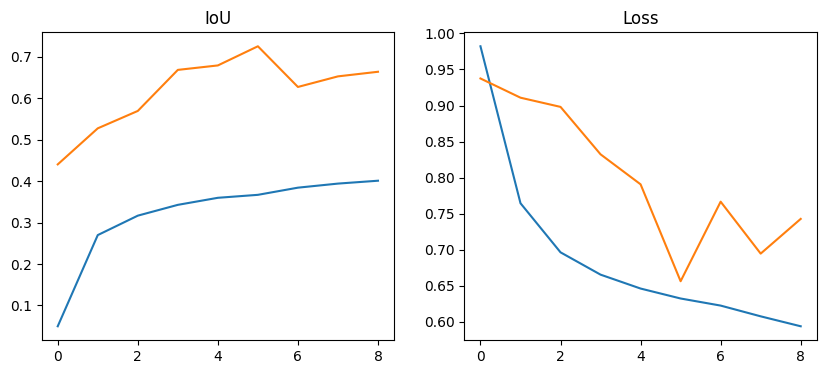

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['iou_metric'])
plt.plot(history.history['val_iou_metric'])
plt.title("IoU")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
Min: 0.0
Max: 0.9989605
Mean: 3.2207827e-05


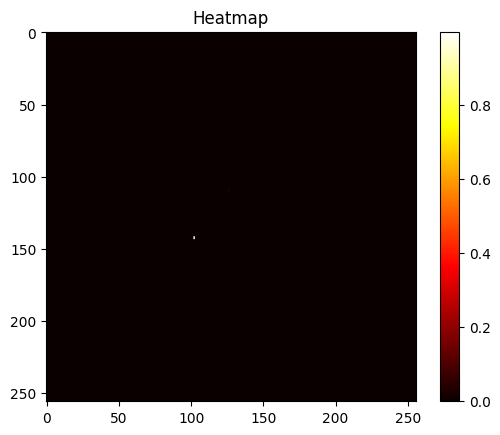

In [ ]:
X,y=val_gen[0]
pred=model.predict(X[0:1])[0]

print("Min:",np.min(pred))
print("Max:",np.max(pred))
print("Mean:",np.mean(pred))

plt.imshow(pred.squeeze(),cmap='hot')
plt.colorbar()
plt.title("Heatmap")
plt.show()

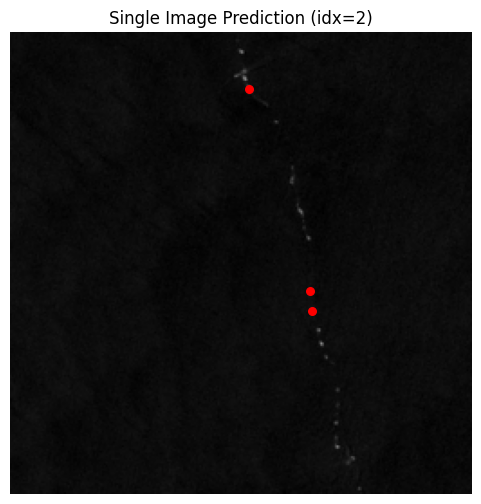

Min: 0.0
Max: 0.99013287
Mean: 3.8073144e-05


In [ ]:
TH = 0.15
idx = 2   # you can change
X_batch, y_batch = val_gen[0]
pred = model.predict(X_batch[idx:idx+1], verbose=0)[0].squeeze()
mask = pred > TH
y_coords, x_coords = np.where(mask)

plt.figure(figsize=(6,6))
plt.imshow(X_batch[idx][:,:,0], cmap='gray')
plt.scatter(x_coords, y_coords, c='red', s=30)

plt.title(f"Single Image Prediction (idx={idx})")
plt.axis('off')
plt.show()

# stats
print("Min:", np.min(pred))
print("Max:", np.max(pred))
print("Mean:", np.mean(pred))

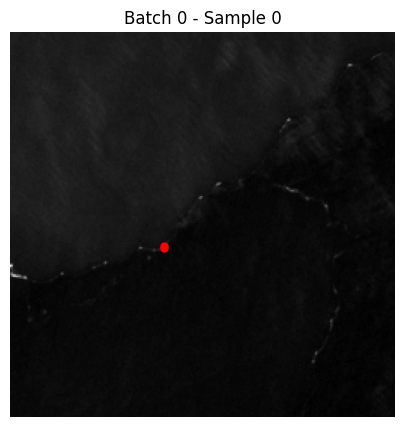

Batch 0, Sample 0
Max: 0.9989605 Mean: 3.2207827e-05
----------------------------------------


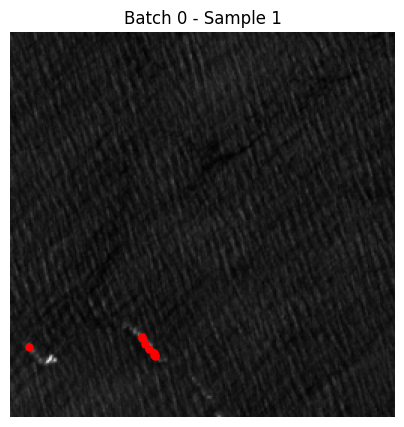

Batch 0, Sample 1
Max: 0.9997197 Mean: 0.00011035916
----------------------------------------


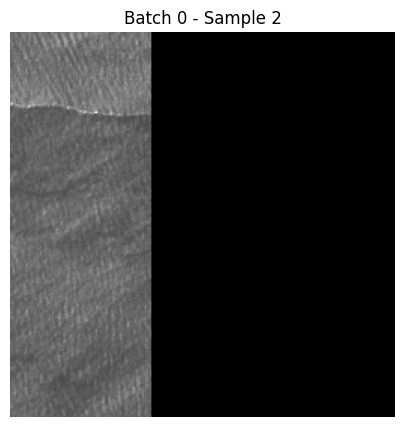

Batch 0, Sample 2
Max: 0.013177447 Mean: 3.1864903e-07
----------------------------------------


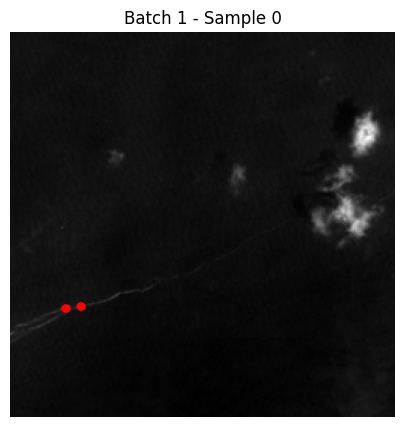

Batch 1, Sample 0
Max: 0.9985715 Mean: 6.015323e-05
----------------------------------------


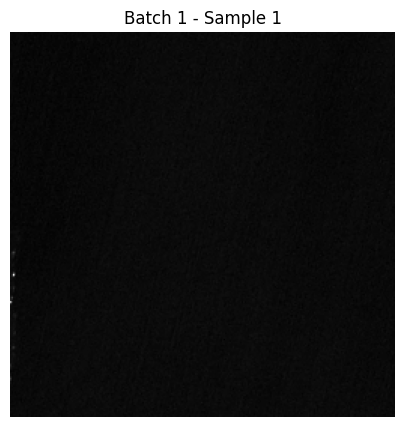

Batch 1, Sample 1
Max: 2.3053154e-07 Mean: 6.65455e-12
----------------------------------------


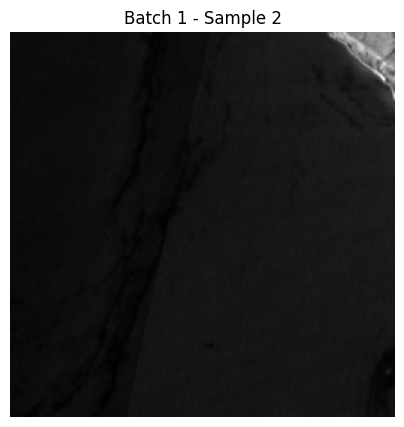

Batch 1, Sample 2
Max: 0.09886185 Mean: 1.5164703e-06
----------------------------------------


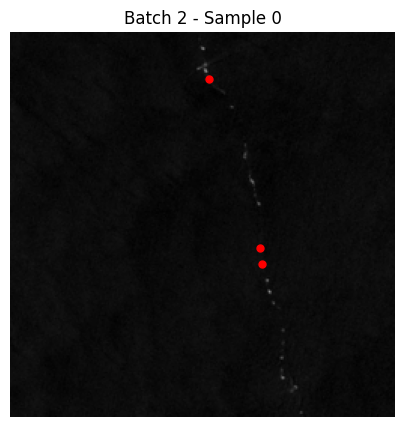

Batch 2, Sample 0
Max: 0.99013287 Mean: 3.8073144e-05
----------------------------------------


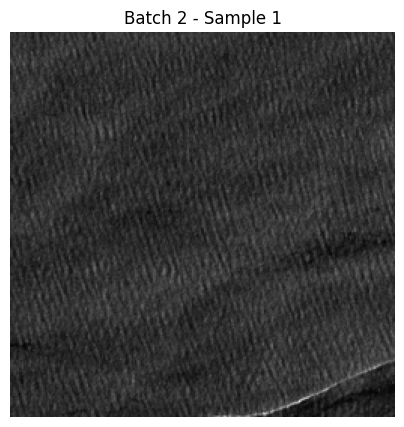

Batch 2, Sample 1
Max: 2.4265968e-05 Mean: 5.6421395e-10
----------------------------------------


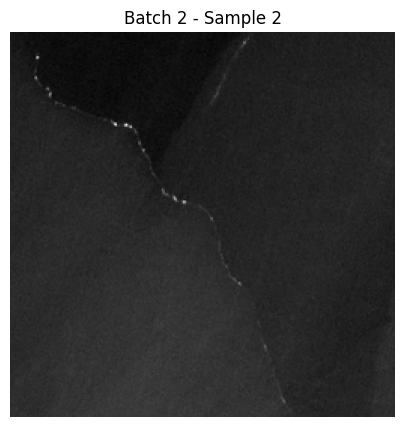

Batch 2, Sample 2
Max: 0.010231623 Mean: 2.2923139e-07
----------------------------------------


In [ ]:
TH = 0.15

num_batches = min(3, len(val_gen))

for b in range(num_batches):

    X_batch, y_batch = val_gen[b]

    num_samples = min(3, len(X_batch))  # 3 samples per batch

    for i in range(num_samples):

        pred = model.predict(X_batch[i:i+1], verbose=0)[0].squeeze()
        mask = pred > TH

        y_coords, x_coords = np.where(mask)

        plt.figure(figsize=(5,5))
        plt.imshow(X_batch[i][:,:,0], cmap='gray')
        plt.scatter(x_coords, y_coords, c='red', s=25)

        plt.title(f"Batch {b} - Sample {i}")
        plt.axis('off')
        plt.show()

        # stats
        print(f"Batch {b}, Sample {i}")
        print("Max:", np.max(pred), "Mean:", np.mean(pred))
        print("-"*40)

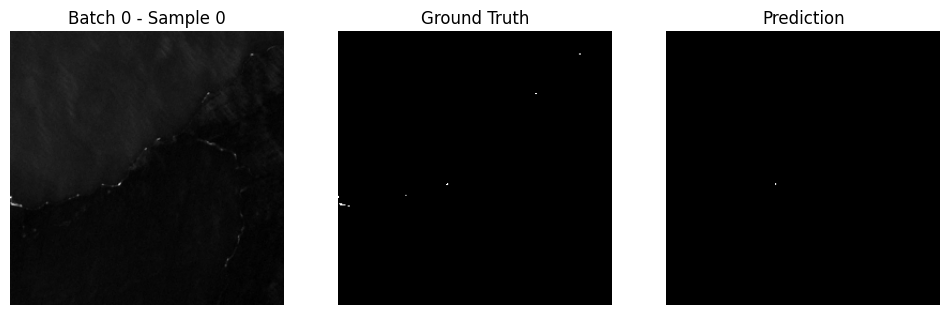

Batch 0, Sample 0
Max: 0.9989605
Mean: 3.2207827e-05
----------------------------------------


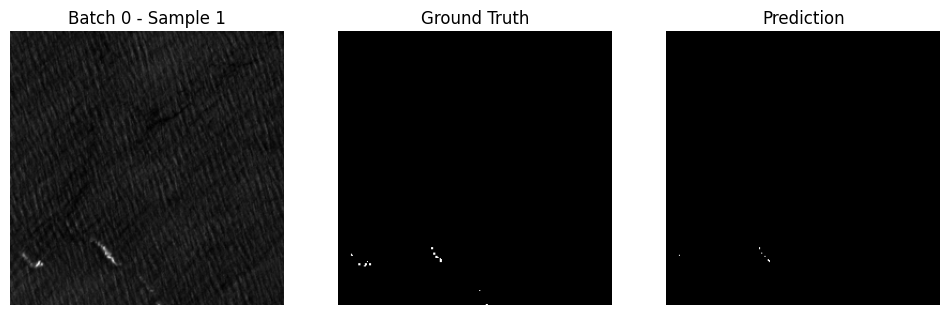

Batch 0, Sample 1
Max: 0.9997197
Mean: 0.00011035916
----------------------------------------


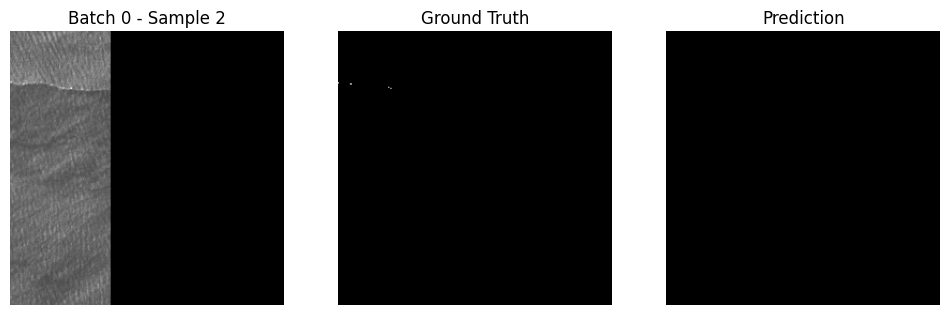

Batch 0, Sample 2
Max: 0.013177447
Mean: 3.1864903e-07
----------------------------------------


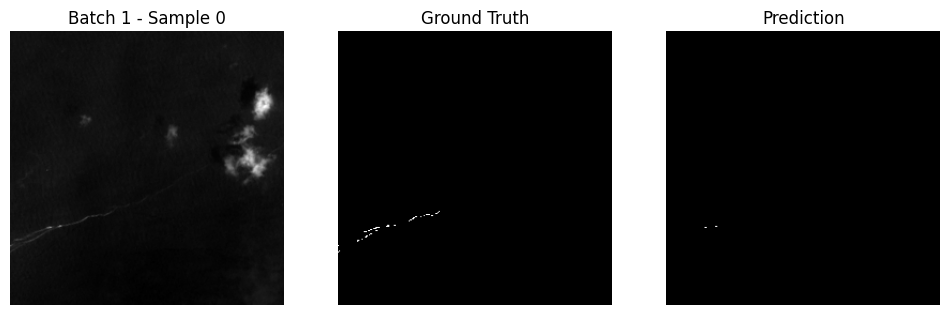

Batch 1, Sample 0
Max: 0.9985715
Mean: 6.015323e-05
----------------------------------------


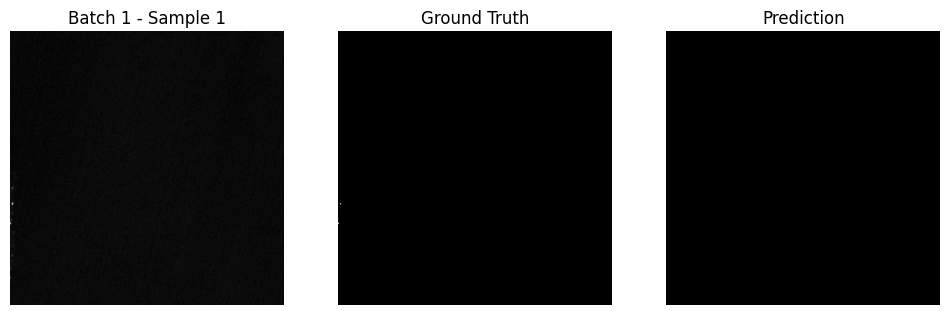

Batch 1, Sample 1
Max: 2.3053154e-07
Mean: 6.65455e-12
----------------------------------------


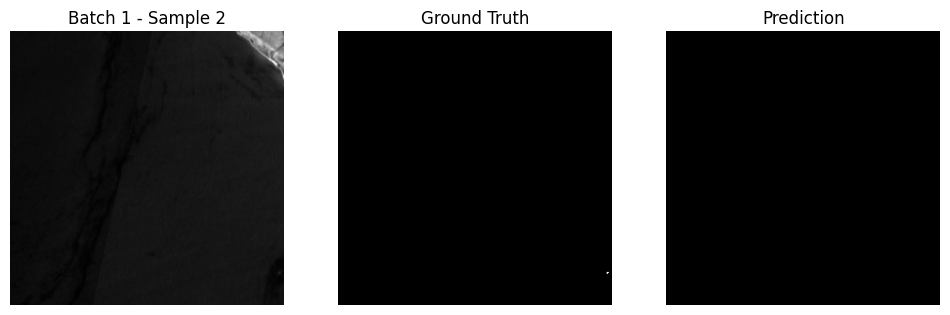

Batch 1, Sample 2
Max: 0.09886185
Mean: 1.5164703e-06
----------------------------------------


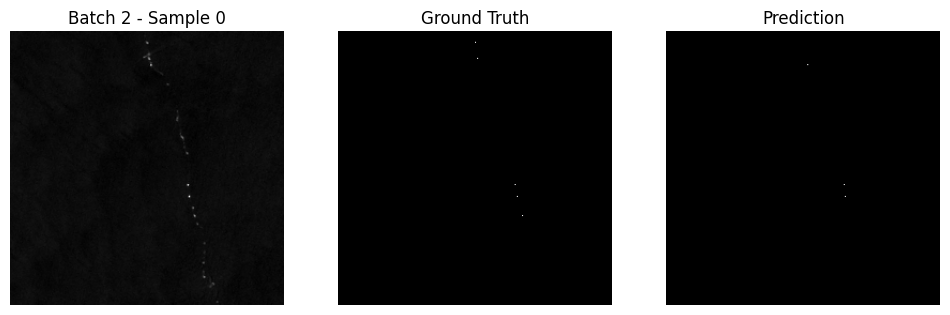

Batch 2, Sample 0
Max: 0.99013287
Mean: 3.8073144e-05
----------------------------------------


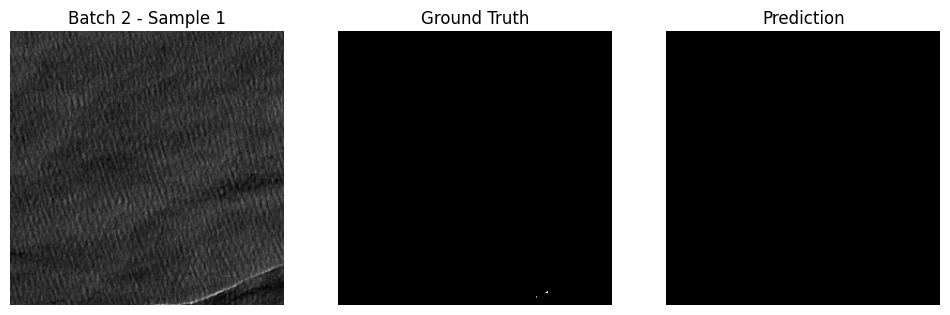

Batch 2, Sample 1
Max: 2.4265968e-05
Mean: 5.6421395e-10
----------------------------------------


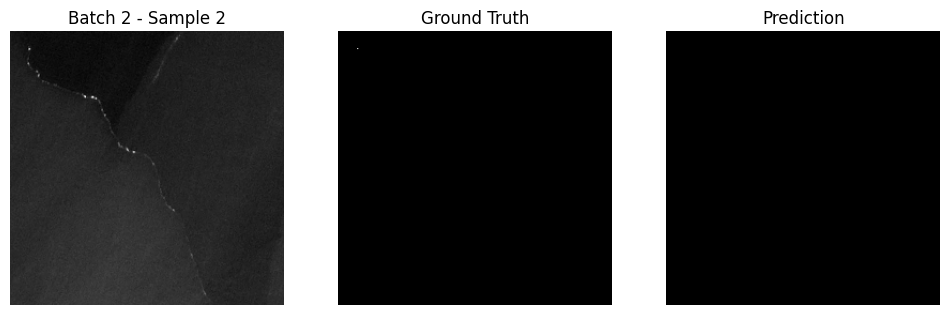

Batch 2, Sample 2
Max: 0.010231623
Mean: 2.2923139e-07
----------------------------------------


In [ ]:
TH = 0.15

num_batches = min(3, len(val_gen))

for b in range(num_batches):
    X_batch, y_batch = val_gen[b]

    num_samples = min(3, len(X_batch))

    for i in range(num_samples):
        pred = model.predict(X_batch[i:i+1], verbose=0)[0]
        mask = pred.squeeze() > TH

        plt.figure(figsize=(12,4))

        # Input
        plt.subplot(1,3,1)
        plt.imshow(X_batch[i][:,:,0], cmap='gray')
        plt.title(f"Batch {b} - Sample {i}")
        plt.axis('off')

        # Ground Truth
        plt.subplot(1,3,2)
        plt.imshow(y_batch[i].squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        # Prediction
        plt.subplot(1,3,3)
        plt.imshow(mask, cmap='gray')
        plt.title("Prediction")
        plt.axis('off')

        plt.show()

        # print stats
        print(f"Batch {b}, Sample {i}")
        print("Max:", np.max(pred))
        print("Mean:", np.mean(pred))
        print("-"*40)